# Read the dataset

In [1]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.keys()

n_samples, n_features = digits.data.shape
print((n_samples, n_features))


print("Shape of an item: ", digits.data[0].shape)
print("Data type of an item: ", type(digits.data[0]))
print("Shape of an item: ", digits.images[0].shape)
print("Data tpye of an item: ", type(digits.images[0]))

(1797, 64)
Shape of an item:  (64,)
Data type of an item:  <class 'numpy.ndarray'>
Shape of an item:  (8, 8)
Data tpye of an item:  <class 'numpy.ndarray'>


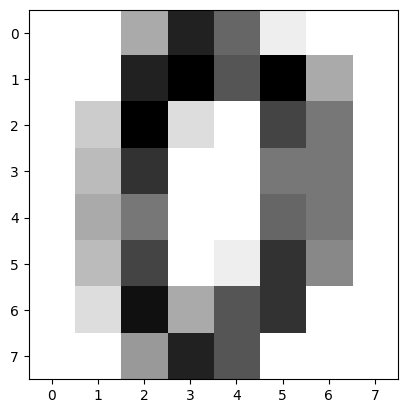

In [2]:
import matplotlib.pyplot as plt
plt.imshow(digits.images[0], cmap='binary')
plt.show()

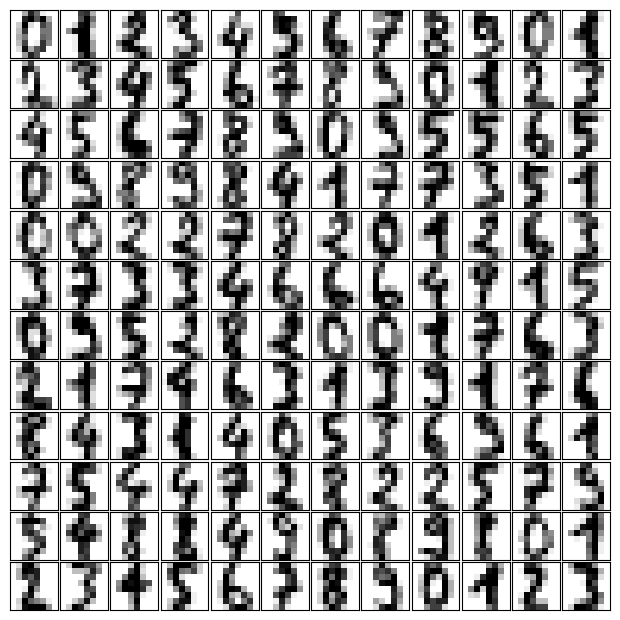

In [4]:
# set up the figure
fig = plt.figure(figsize=(6, 6))  # figure size in inches
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

# plot the digits: each image is 8x8 pixels
for i in range(144):
    ax = fig.add_subplot(12, 12, i + 1, xticks=[], yticks=[])
    ax.imshow(digits.images[i], cmap=plt.cm.binary, interpolation='nearest')

    # label the image with the target value
    #ax.text(0, 7, str(digits.target[i]))

# Create train, test and validation

Training dataset length: 1437
Validation dataset length: 180
Testing dataset length: 180


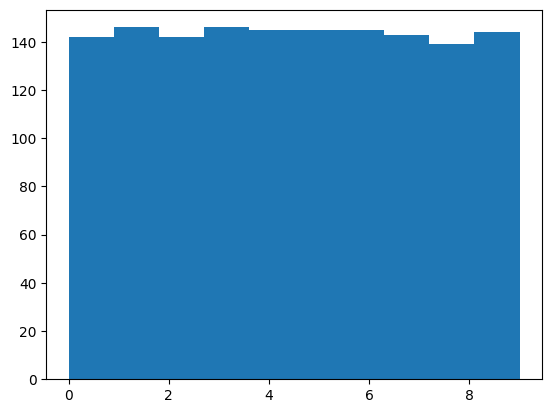

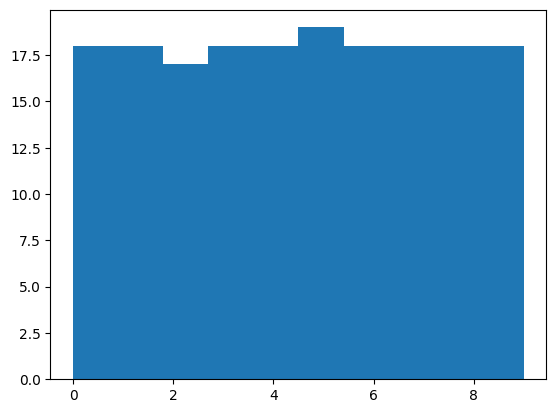

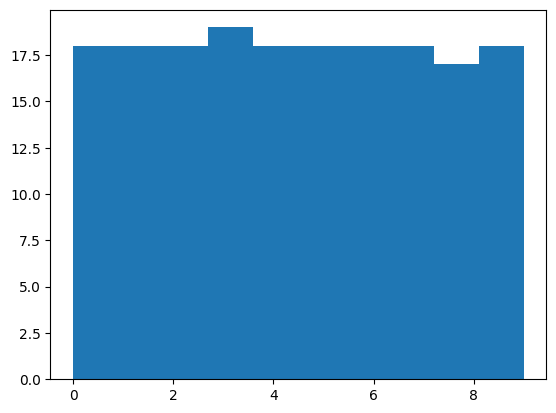

In [6]:
from sklearn.model_selection import train_test_split
import numpy as np
# set up the figure
digits.images = digits.images[:, np.newaxis, :, :]
X_train, X_remain, Y_train, Y_remain  = train_test_split(digits.images, digits.target, test_size=0.20, shuffle = True, stratify=(digits.target))
X_val, X_test, Y_val, Y_test  = train_test_split(X_remain, Y_remain, test_size=0.50, shuffle = True, stratify=(Y_remain))


print("Training dataset length:", len(X_train))
print("Validation dataset length:", len(X_val))
print("Testing dataset length:", len(X_test))


plt.hist(Y_train)
plt.show()

plt.hist(Y_val)
plt.show()

plt.hist(Y_test)
plt.show()

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

Train_tensors = torch.from_numpy(X_train).float()
Val_tensors = torch.from_numpy(X_val).float()
Test_tensors = torch.from_numpy(X_test).float()

train_label = torch.from_numpy(Y_train)
val_label = torch.from_numpy(Y_val)
test_label = torch.from_numpy(Y_test)


# Wrap the tensors in a TensorDataset object
dataset_train = TensorDataset(Train_tensors, train_label)
dataset_val = TensorDataset(Val_tensors, val_label)

In [8]:
dataset_val.tensors[0].shape

torch.Size([180, 1, 8, 8])

# Network definition

In [9]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1) #8+2-3+1 = 8
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 2 * 2, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # -> [batch, 32, 4, 4]
        x = self.pool(F.relu(self.conv2(x)))   # -> [batch, 64, 2, 2]
        x = x.view(-1, 64 * 2 * 2)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

'''
# Define the MLP architecture
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MLP, self).__init__()


        self.block = nn.Sequential( nn.Linear(input_dim, 32),
                                    nn.ReLU(),
                                    #nn.Linear(4096, 1024),
                                    #nn.ReLU(),
                                    #nn.Dropout(0.4),
                                    #nn.Linear(1024, 256),
                                    #nn.ReLU(),
                                    nn.Linear(32, 10)
                                )

    def forward(self, x):   #FORWARD STEP
        out = self.block(x)
        return out

100 bach size 10 = 10 batch
100 bach size 20 = 5 batch
'''

# Define the training function
def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train()
    train_acc = 0.0
    train_loss = 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device).long()
        optimizer.zero_grad()
        output = model(data) #forward
        loss = criterion(output, target)  #calcolo loss
        loss.backward() #calcolo gradienti
        optimizer.step() #agg pesi

        train_loss += loss.item()
        train_acc += (output.argmax(dim=1) == target).sum().item()
    train_acc /= len(train_loader.dataset)
    train_loss /= len(train_loader.dataset)
    return train_loss, train_acc

# Define the validation function
def validate(model, device, val_loader, criterion):
    model.eval()
    val_loss = 0.0
    val_acc = 0.0
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device).long()
            output = model(data)
            loss = criterion(output, target)
            val_loss += loss.item()
            val_acc += (output.argmax(dim=1) == target).sum().item()
    val_loss /= len(val_loader.dataset)
    val_acc /= len(val_loader.dataset)
    return val_loss, val_acc

# Train the network

Epoch 1/100, Train Loss: 0.0362, Train Acc: 0.6283, Validation Loss: 0.0074, Validation Acc: 0.9222
Epoch 2/100, Train Loss: 0.0049, Train Acc: 0.9499, Validation Loss: 0.0022, Validation Acc: 0.9778
Epoch 3/100, Train Loss: 0.0023, Train Acc: 0.9784, Validation Loss: 0.0029, Validation Acc: 0.9667
Epoch 4/100, Train Loss: 0.0020, Train Acc: 0.9827, Validation Loss: 0.0007, Validation Acc: 1.0000
Epoch 5/100, Train Loss: 0.0014, Train Acc: 0.9882, Validation Loss: 0.0113, Validation Acc: 0.9333
Epoch 6/100, Train Loss: 0.0033, Train Acc: 0.9635, Validation Loss: 0.0059, Validation Acc: 0.9611
Epoch 7/100, Train Loss: 0.0024, Train Acc: 0.9771, Validation Loss: 0.0022, Validation Acc: 0.9778
Epoch 8/100, Train Loss: 0.0016, Train Acc: 0.9827, Validation Loss: 0.0005, Validation Acc: 0.9944
Epoch 9/100, Train Loss: 0.0019, Train Acc: 0.9852, Validation Loss: 0.0023, Validation Acc: 0.9778
Epoch 10/100, Train Loss: 0.0025, Train Acc: 0.9790, Validation Loss: 0.0034, Validation Acc: 0.9556

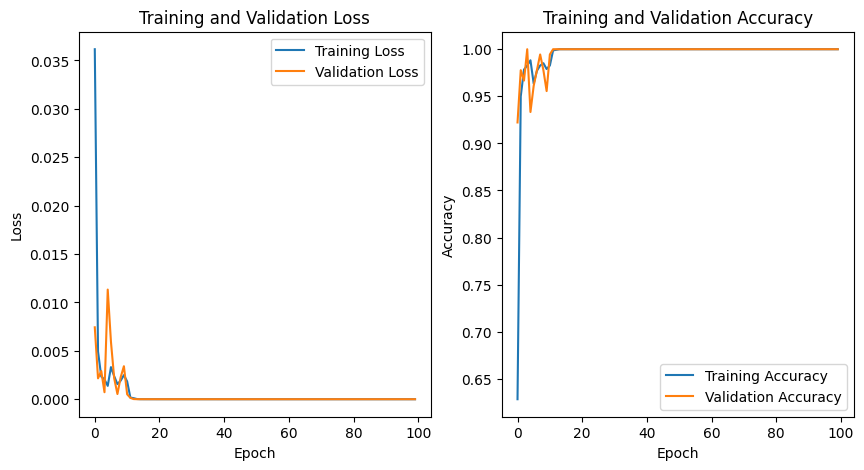

In [18]:
input_dim = 64
output_dim = 10
lr = 0.01
num_epochs = 100
batch_size = 32


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model, device, optimizer, and criterion
model = CNN().to(device) #MLP(input_dim, output_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr = lr) #optim.SGD(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

# Load the training and validation data loaders

# Initialize the lists to store the training and validation losses and accuracies
train_losses = []
train_accs = []
val_losses = []
val_accs = []
best_loss = 0.0

# Train the model
for epoch in range(num_epochs):
    # CREATE BATCHES
    train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(dataset_val, batch_size=batch_size, shuffle=True)
    #1. WORK ON TRAIN SET
    # FOR EACH BATCH b:
    #     FORWARD STEP -> y_pred = MLP(b)
    #     COMPUTE THE LOSS -> Loss = criterion(y_pred, label)
    #     COMPUTE THE GRADIENTS
    #     UPDATE THE NETWORK
    #2. WORK ON VALIDATION SET
    # FOR EACH BATCH b:
    #     FORWARD STEP -> y_pred = MLP(b)
    #     COMPUTE THE LOSS -> Loss = criterion(y_pred, label)
    train_loss, train_acc = train(model, device, train_loader, optimizer, criterion, epoch)
    val_loss, val_acc = validate(model, device, val_loader, criterion)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Validation Loss: {val_loss:.4f}, Validation Acc: {val_acc:.4f}')

    if epoch == 0 or val_loss<best_loss:
      best_loss = val_loss
      torch.save(model.state_dict(),  'best_weights.pth')

# Plot the training curves
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Training Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

# Final training

In [13]:
input_dim = 64
output_dim = 10
lr = 0.001
num_epochs = 20
batch_size = 32

X_train_new = np.concatenate([X_train,X_val])
Y_train_new = np.concatenate([Y_train, Y_val])

Train_tensors = torch.from_numpy(X_train_new).float()
train_label = torch.from_numpy(Y_train_new)

dataset_train = TensorDataset(Train_tensors, train_label)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model, device, optimizer, and criterion
model = CNN().to(device) #MLP(input_dim, output_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr = lr) #optim.SGD(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

# Load the training and validation data loaders

# Initialize the lists to store the training and validation losses and accuracies
train_losses = []
train_accs = []
val_losses = []
val_accs = []
best_loss = 0.0

# Train the model
for epoch in range(num_epochs):
    # CREATE BATCHES
    train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
    train_loss, train_acc = train(model, device, train_loader, optimizer, criterion, epoch)
    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')

torch.save(model.state_dict(),  'final_weights.pth')

Epoch 1/20, Train Loss: 0.0345, Train Acc: 0.6994
Epoch 2/20, Train Loss: 0.0052, Train Acc: 0.9567
Epoch 3/20, Train Loss: 0.0031, Train Acc: 0.9740
Epoch 4/20, Train Loss: 0.0016, Train Acc: 0.9858
Epoch 5/20, Train Loss: 0.0014, Train Acc: 0.9907
Epoch 6/20, Train Loss: 0.0006, Train Acc: 0.9969
Epoch 7/20, Train Loss: 0.0004, Train Acc: 0.9975
Epoch 8/20, Train Loss: 0.0008, Train Acc: 0.9957
Epoch 9/20, Train Loss: 0.0005, Train Acc: 0.9957
Epoch 10/20, Train Loss: 0.0002, Train Acc: 0.9988
Epoch 11/20, Train Loss: 0.0001, Train Acc: 1.0000
Epoch 12/20, Train Loss: 0.0001, Train Acc: 1.0000
Epoch 13/20, Train Loss: 0.0000, Train Acc: 1.0000
Epoch 14/20, Train Loss: 0.0000, Train Acc: 1.0000
Epoch 15/20, Train Loss: 0.0000, Train Acc: 1.0000
Epoch 16/20, Train Loss: 0.0000, Train Acc: 1.0000
Epoch 17/20, Train Loss: 0.0000, Train Acc: 1.0000
Epoch 18/20, Train Loss: 0.0000, Train Acc: 1.0000
Epoch 19/20, Train Loss: 0.0000, Train Acc: 1.0000
Epoch 20/20, Train Loss: 0.0000, Train A

# Compute the prediction on test set

In [14]:
import pandas as pd

model.load_state_dict(torch.load('final_weights.pth'))
model.eval()
test_predictions = []
test_prob = []

for inputs in Test_tensors:
  # Flatten the input data
  #inputs = inputs.view(-1, 64).to(device)
  # Forward pass
  outputs = model(inputs.to(device))
  # Get the predicted class
  _, predicted = torch.max(outputs.data, 1)
  probability = torch.nn.functional.softmax(outputs, dim=1)
  probability = probability.detach().cpu().numpy()[:, predicted]
  # Store the predictions
  test_predictions.extend(predicted.cpu().numpy())
  test_prob.extend(probability)

acc = (test_predictions == Y_test).sum()/len(Y_test)
print("Accuracy: ", acc)
print(pd.crosstab(Y_test, test_predictions, rownames=['Actual'], colnames=['Predicted'], margins=True))

Accuracy:  0.9888888888888889
Predicted   0   1   2   3   4   5   6   7   8   9  All
Actual                                                
0          18   0   0   0   0   0   0   0   0   0   18
1           0  18   0   0   0   0   0   0   0   0   18
2           0   0  18   0   0   0   0   0   0   0   18
3           0   0   0  19   0   0   0   0   0   0   19
4           0   0   0   0  18   0   0   0   0   0   18
5           0   0   0   0   1  16   0   0   0   1   18
6           0   0   0   0   0   0  18   0   0   0   18
7           0   0   0   0   0   0   0  18   0   0   18
8           0   0   0   0   0   0   0   0  17   0   17
9           0   0   0   0   0   0   0   0   0  18   18
All        18  18  18  19  19  16  18  18  17  19  180


In [15]:
print(outputs)
print(torch.nn.functional.softmax(outputs, dim=1))

tensor([[-7.2319, 14.6369, -4.6025, -4.6161,  1.7684, -7.4854, -5.4989, -2.1935,
          0.8294,  0.7815]], device='cuda:0', grad_fn=<AddmmBackward0>)
tensor([[3.1803e-10, 1.0000e+00, 4.4096e-09, 4.3502e-09, 2.5778e-06, 2.4682e-10,
         1.7993e-09, 4.9050e-08, 1.0080e-06, 9.6086e-07]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
